In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
stock_data = pd.read_csv("Cleaned Stock Prices Data Set.csv")
stock_data.head(5)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [3]:
X = stock_data[["open", "high", "low", "close", "volume"]]

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
print(X_scaled[:5])

[[-0.60394474 -0.59927555 -0.60149586 -0.60123875  0.57644031]
 [-0.06868507 -0.07386256 -0.06654434 -0.07243929  6.62505812]
 [ 0.23659923  0.24188411  0.23602984  0.23031819 -0.45078242]
 [-0.33736349 -0.34016397 -0.33839566 -0.33890116  0.03831937]
 [-0.16006972 -0.16520745 -0.15981366 -0.1623998  -0.3772073 ]]


In [6]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

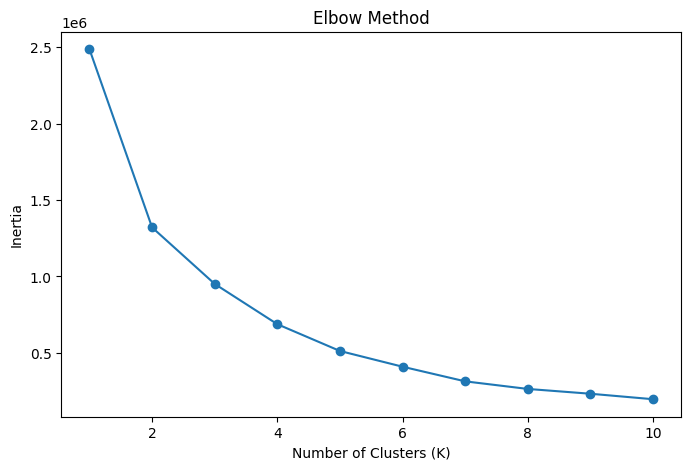

In [7]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.show()

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [11]:
stock_data["Cluster"] = kmeans.labels_

In [12]:
stock_data.head(10)

,symbol,date,open,high,low,close,volume,Cluster
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,0
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,3
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2
5,ABT,2014-01-02,38.0900,38.4000,38.0000,38.2300,4967472,2
6,ACN,2014-01-02,81.5000,81.9200,81.0900,81.1300,2405384,2
7,ADBE,2014-01-02,59.0600,59.5300,58.9400,59.2900,2746370,2
8,ADI,2014-01-02,49.5200,49.7500,49.0400,49.2800,2799092,2
9,ADM,2014-01-02,43.2200,43.2900,42.7900,42.9900,2753765,2


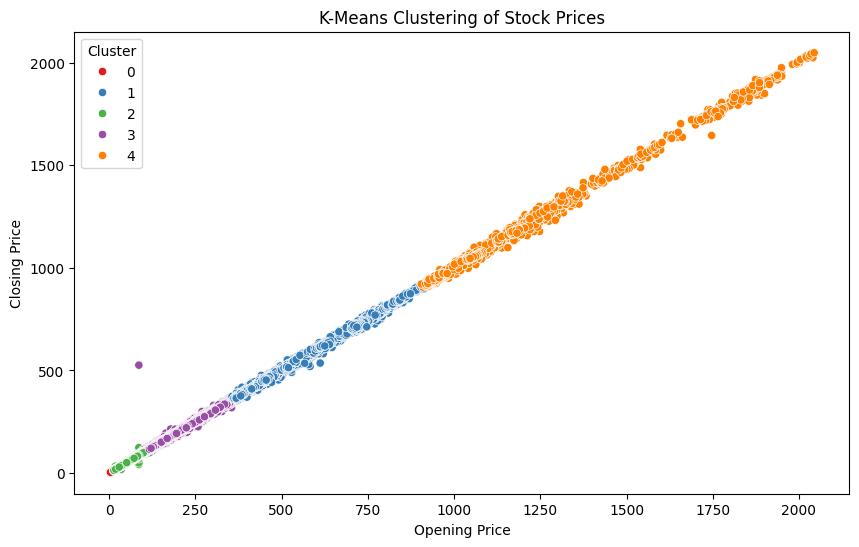

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="open",
    y="close",
    hue="Cluster",
    palette="Set1",
    data=stock_data
)

plt.title("K-Means Clustering of Stock Prices")
plt.xlabel("Opening Price")
plt.ylabel("Closing Price")

plt.show()

In [ ]:
# Conclusion

K-Means clustering was applied to the stock price dataset after standardizing the numerical features (Open, High, Low, Close, and Volume) using StandardScaler. The Elbow Method was used to determine the optimal number of clusters, and five clusters were selected for the final model.

The algorithm successfully grouped trading days with similar stock price characteristics into distinct clusters. A scatter plot of Opening Price versus Closing Price showed clear separation between the clusters, indicating that K-Means effectively identified patterns within the data.

The visualization also revealed a strong positive relationship between opening and closing prices, as most data points followed a nearly straight-line pattern. Overall, the clustering analysis demonstrated how unsupervised machine learning can be used to identify similar observations without requiring predefined labels.